# 1. Basic parameters

In [1]:
import networkx as nx
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt
import matplotlib.axes as maxes
import matplotlib.patches as mpatches

N_STATE = 20
N_ITER = 100
ITERS = np.arange(N_ITER)
ALPHA = 0.3

# 2. Define the graph topology

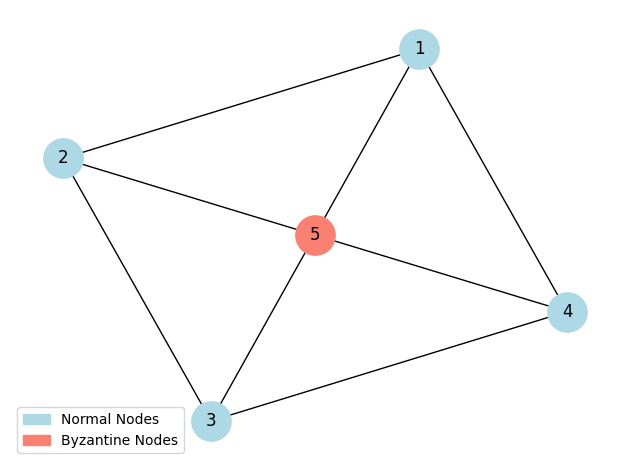

In [2]:
NORMAL_NODES = ["1", "2", "3", "4"]
NORMAL_EDGES = [
    ("1", "2"),
    ("2", "3"),
    ("3", "4"),
    ("4", "1"),
]
BYZANTINE_NODES = ["5"]
BYZANTINE_EDGES = [("1", "5"), ("2", "5"), ("3", "5"), ("4", "5"), ("5", "1")]

NODES = NORMAL_NODES + BYZANTINE_NODES
EDGES = NORMAL_EDGES + BYZANTINE_EDGES

N_NORMAL = len(NORMAL_NODES)
N_BYZANTINE = len(BYZANTINE_NODES)
N_NODES = N_NORMAL + N_BYZANTINE

plt.rcdefaults()

fig, ax = plt.subplots()

G = nx.Graph()
G.add_nodes_from(NODES)
G.add_edges_from(EDGES)

pos = nx.spring_layout(G, seed=1, k=0.8)

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=NORMAL_NODES,
    node_color="lightblue",
    node_size=800,
    ax=ax,
)

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=BYZANTINE_NODES,
    node_color="salmon",
    node_size=800,
    ax=ax,
)

nx.draw_networkx_edges(G, pos, ax=ax)
nx.draw_networkx_labels(G, pos, ax=ax)

blue_patch = mpatches.Patch(color="lightblue", label="Normal Nodes")
red_patch = mpatches.Patch(color="salmon", label="Byzantine Nodes")

ax.legend(handles=[blue_patch, red_patch], loc="lower left")
ax.axis("off")
plt.tight_layout()

# 3. Attacker model

In [6]:
import ray

from conops import Network, Graph


@ray.remote(num_cpus=1)
class Node:
    def __init__(
        self,
        name: str,
        neighbors: dict[str, float],
        n_state: int,
        alpha: float,
        n_iter: int,
    ) -> None:
        self.network = Network(name, neighbors)
        self.network.start()

        self.n_state = n_state
        self.alpha = alpha
        self.n_iter = n_iter

        self.upper_bound = 100.0
        self.lower_bound = -100.0

    def __ray_shutdown__(self):
        self.network.stop()

    @ray.method
    def byz_node(self) -> None:
        import numpy.linalg as la
        from numpy.random import seed, uniform

        network = self.network

        seed(int(network.node_id))  # Ensure reproducibility for each node
        attack_values = {
            "1": uniform(self.lower_bound, self.upper_bound, self.n_state),
            "2": uniform(self.lower_bound, self.upper_bound, self.n_state),
            "3": uniform(self.lower_bound, self.upper_bound, self.n_state),
            "4": uniform(self.lower_bound, self.upper_bound, self.n_state),
        }

        honest_adj = {
            "1": ["2", "4"],
            "2": ["1", "3"],
            "3": ["2", "4"],
            "4": ["3", "1"],
        }

        honest_eta = 0.001
        attack_factor = 1.0

        unit_vec = np.zeros(self.n_state)
        unit_vec[0] = 1.0

        while network.round_id < self.n_iter - 1:
            n_states = network.neighborwise_exchange(attack_values)

            diam = max(
                la.norm(n_states[i] - n_states[j], ord=np.inf)
                for i in honest_adj
                for j in honest_adj[i]
            )

            for i in honest_adj:
                n_i = honest_adj[i]
                cm_i = np.median(
                    [n_states[j] for j in n_i] + [attack_values[i]], axis=0
                )
                bias = (diam + (1 / (honest_eta * len(n_i))) * attack_factor) * unit_vec
                attack_values[i] = cm_i + bias

            network.next_round()

        network._reset()

    @ray.method
    def arepc_node(
        self,
    ) -> tuple[npt.NDArray[np.float64], dict[str, npt.NDArray[np.float64]]]:
        from numpy import zeros
        from numpy.random import uniform, seed

        network = self.network

        from arepc import ARepC

        agent = ARepC(network, self.alpha, eta=0.005, normalization="sparsemax")

        x = zeros((self.n_iter, self.n_state))
        seed(int(network.node_id))  # Ensure reproducibility for each node
        x[0] = uniform(self.lower_bound, self.upper_bound, self.n_state)

        reps = {neighbor: zeros(self.n_iter - 1) for neighbor in network.neighbors}

        k = network.round_id

        while k < self.n_iter - 1:
            # Compute new state
            x[k + 1] = agent.weighted_mix(x[k])

            # Record normalized weights history
            r = agent.reputations
            for j in network.neighbors:
                reps[j][k] = r[j]

            k = network.next_round()

        network._reset()

        return x, reps


ray.init()

graph = Graph(NODES, EDGES)

nodes = {i: Node.remote(i, graph[i], N_STATE, ALPHA, N_ITER) for i in NODES}

2026-08-21 10:21:08,516	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 


In [7]:
from conops import Graph

graph = Graph(NODES, EDGES)

arepc_refs = {i: nodes[i].arepc_node.remote() for i in NORMAL_NODES}
byz_refs = [nodes[i].byz_node.remote() for i in BYZANTINE_NODES]

arepc_data = {i: ray.get(ref) for i, ref in arepc_refs.items()}
_ = ray.get(byz_refs)

## (2) Reputation

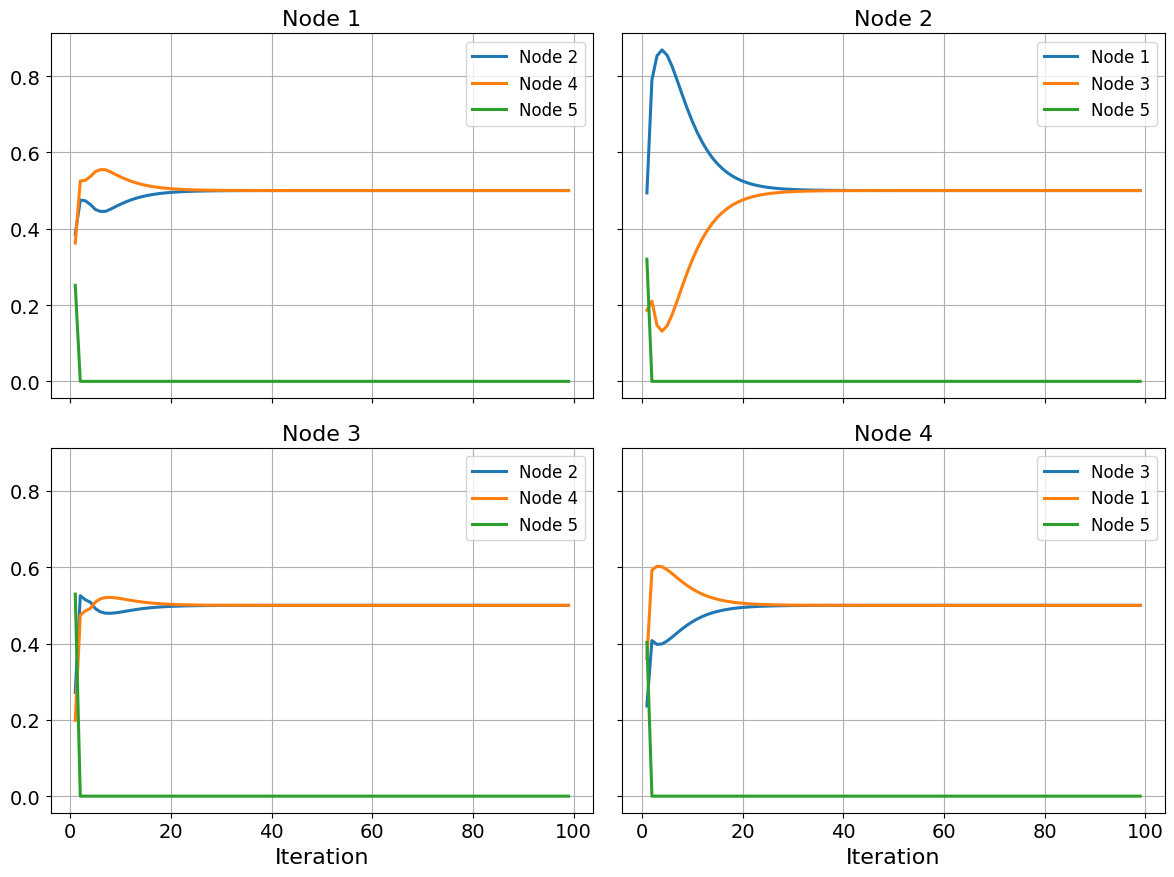

In [8]:
plt.rcParams.update(
    {
        "font.size": 14,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 12,
        "lines.linewidth": 2.2,
    }
)

axes: npt.NDArray
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)
axes_flat = axes.flatten()

arepc_reps = {i: arepc_data[i][1] for i in NORMAL_NODES}

for i, ax in zip(NORMAL_NODES, axes_flat):
    ax: maxes.Axes
    reps_for_i = arepc_reps[i]
    for j in reps_for_i:
        ax.plot(ITERS[1:], reps_for_i[j], label=f"Node {j}")
    ax.set_title(f"Node {i}")
    ax.legend(loc="upper right")
    ax.grid()

    if i in ["3", "4"]:
        ax.set_xlabel("Iteration")

fig.tight_layout()

# 4. Comparison

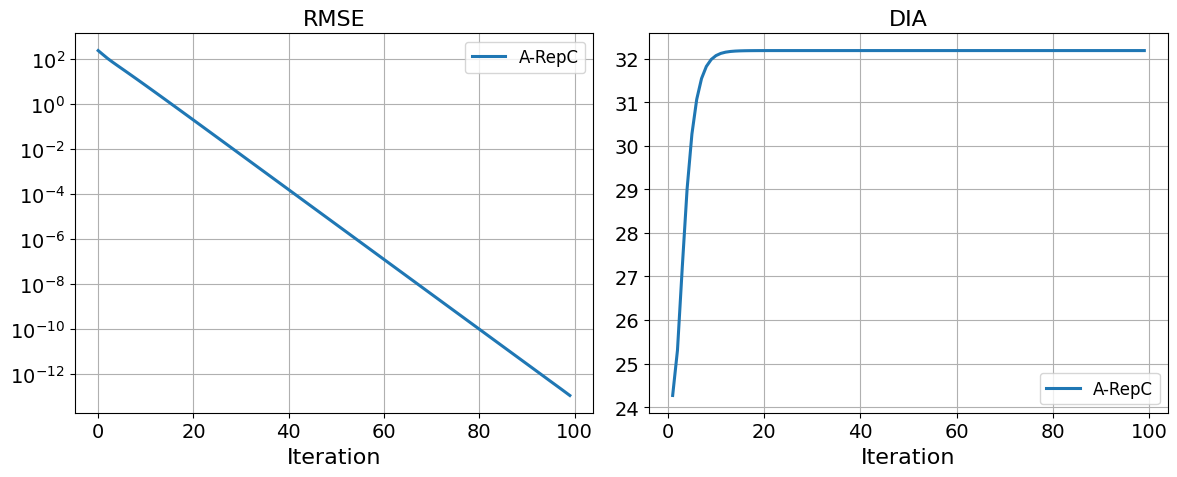

In [9]:
plt.rcParams.update(
    {
        "font.size": 14,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 12,
        "lines.linewidth": 2.2,
    }
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax1: maxes.Axes = axes[0]
ax2: maxes.Axes = axes[1]

arepc_states = np.array([arepc_data[i][0] for i in NORMAL_NODES])
arepc_avg_states: npt.NDArray[np.float64] = np.average(arepc_states, axis=0)
diffs = arepc_states - arepc_avg_states
aprec_rmse = np.sqrt(np.mean(np.sum(diffs**2, axis=2), axis=0))

ax1.semilogy(ITERS, aprec_rmse, label="A-RepC")
ax1.set_xlabel("Iteration")
ax1.set_title("RMSE")
ax1.legend()
ax1.grid()

fig.tight_layout()

arepc_x0_mean = arepc_avg_states[0]
aprec_drift = np.linalg.norm(arepc_avg_states - arepc_x0_mean[None, :], axis=1)

ax2.plot(ITERS[1:], aprec_drift[1:], label="A-RepC")
ax2.set_xlabel("Iteration")
ax2.set_title("DIA")
ax2.legend()
ax2.grid()

fig.tight_layout()

# 5. Shutdown the cluster

In [10]:
ray.shutdown()